  DATASET LOADED SUCCESSFULLY
  Rows    : 6901
  Columns : 20

── Column Names ──
['Logical quotient rating', 'hackathons', 'coding skills rating', 'public speaking points', 'self-learning capability?', 'Extra-courses did', 'certifications', 'workshops', 'reading and writing skills', 'memory capability score', 'Interested subjects', 'interested career area ', 'Type of company want to settle in?', 'Taken inputs from seniors or elders', 'Interested Type of Books', 'Management or Technical', 'hard/smart worker', 'worked in teams ever?', 'Introvert', 'Suggested Job Role']

── Data Types ──
Logical quotient rating                int64
hackathons                             int64
coding skills rating                   int64
public speaking points                 int64
self-learning capability?                str
Extra-courses did                        str
certifications                           str
workshops                                str
reading and writing skills               str
me

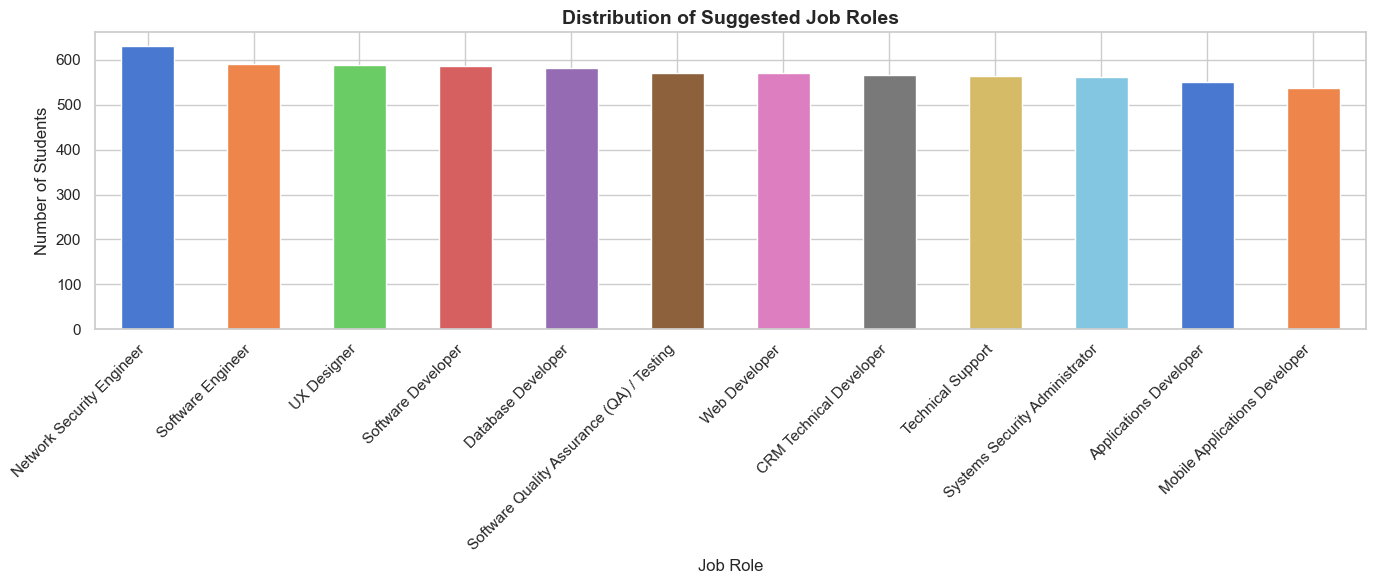

Plot saved: job_role_distribution.png

── Numeric Column Statistics ──
       Logical quotient rating   hackathons  coding skills rating  \
count              6901.000000  6901.000000           6901.000000   
mean                  4.991016     2.999710              5.010723   
std                   2.577704     2.010191              2.568347   
min                   1.000000     0.000000              1.000000   
25%                   3.000000     1.000000              3.000000   
50%                   5.000000     3.000000              5.000000   
75%                   7.000000     5.000000              7.000000   
max                   9.000000     6.000000              9.000000   

       public speaking points  
count             6901.000000  
mean                 4.988263  
std                  2.599500  
min                  1.000000  
25%                  3.000000  
50%                  5.000000  
75%                  7.000000  
max                  9.000000  


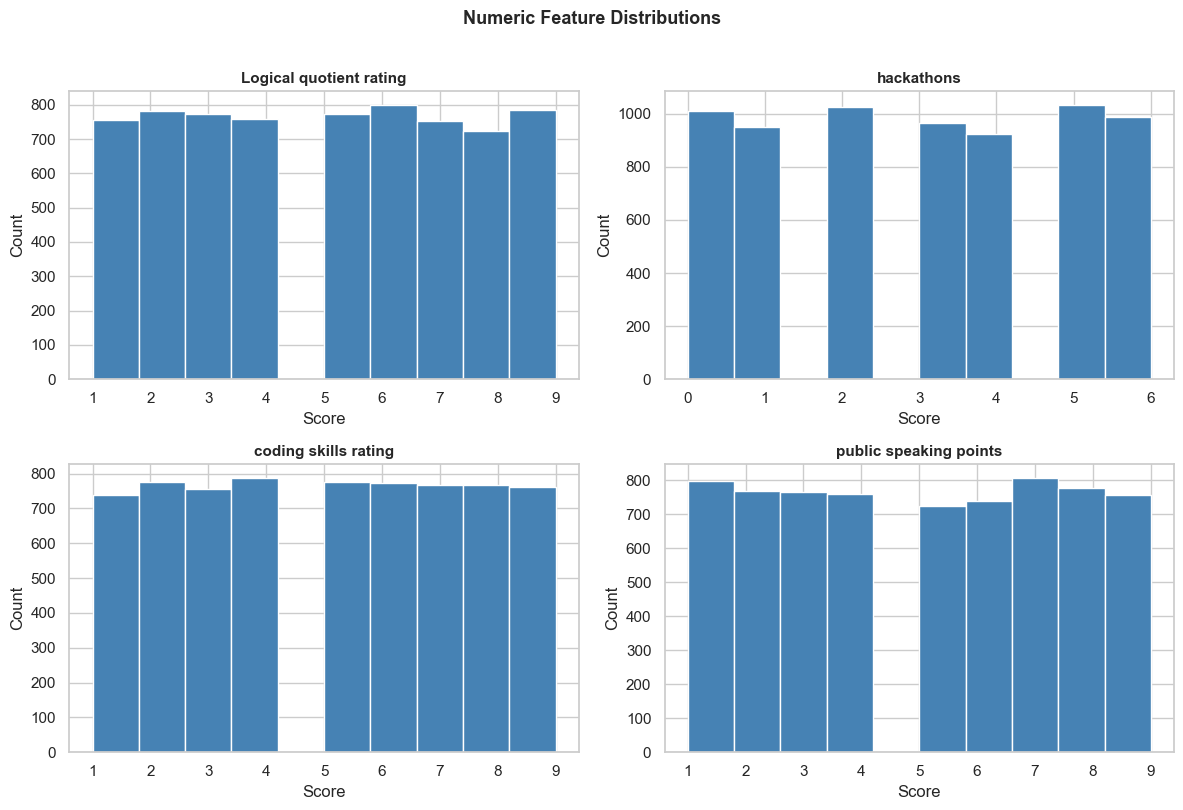

Plot saved: numeric_distributions.png


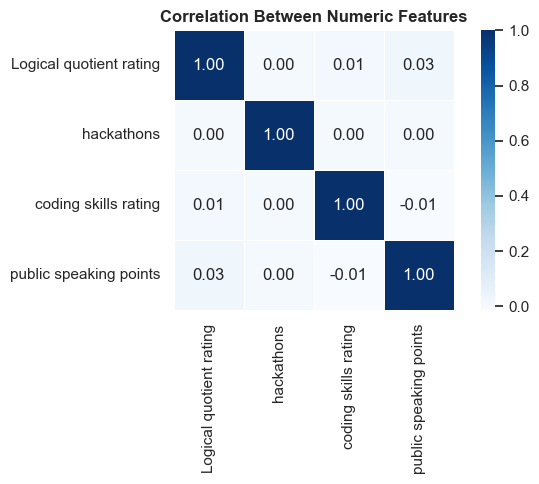

Plot saved: correlation_heatmap.png

── Categorical Column Unique Values ──

self-learning capability?:
self-learning capability?
yes    3496
no     3405
Name: count, dtype: int64

Extra-courses did:
Extra-courses did
no     3529
yes    3372
Name: count, dtype: int64

certifications:
certifications
r programming           803
information security    785
shell programming       783
machine learning        783
full stack              768
hadoop                  764
python                  756
distro making           740
app development         719
Name: count, dtype: int64

workshops:
workshops
database security    897
system designing     891
web technologies     891
hacking              867
testing              852
data science         842
game development     831
cloud computing      830
Name: count, dtype: int64

reading and writing skills:
reading and writing skills
excellent    2328
medium       2315
poor         2258
Name: count, dtype: int64

memory capability score:
memory capab

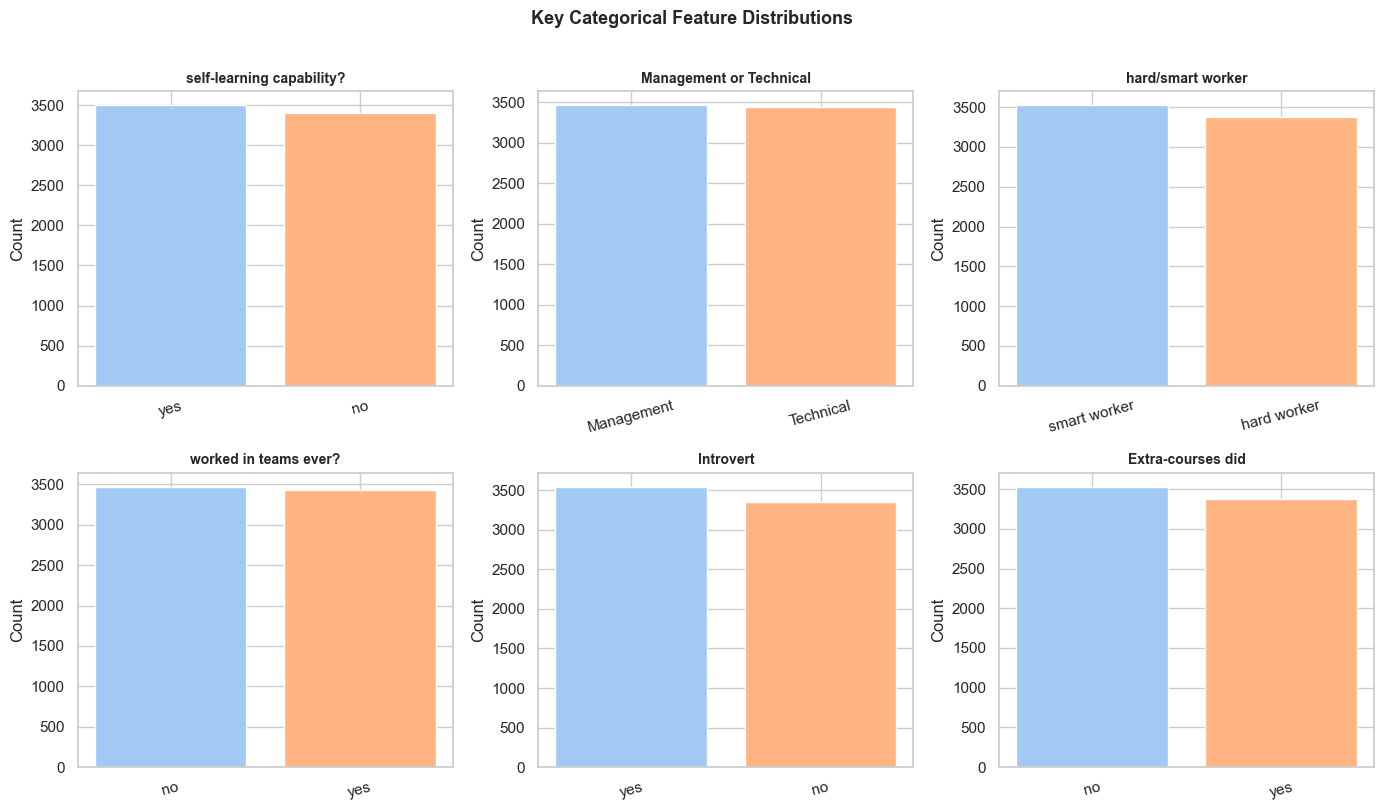

Plot saved: categorical_distributions.png


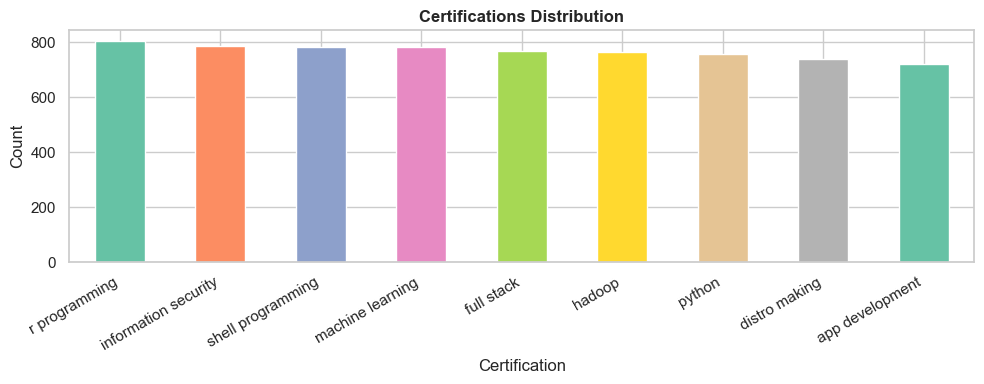

Plot saved: certifications_distribution.png


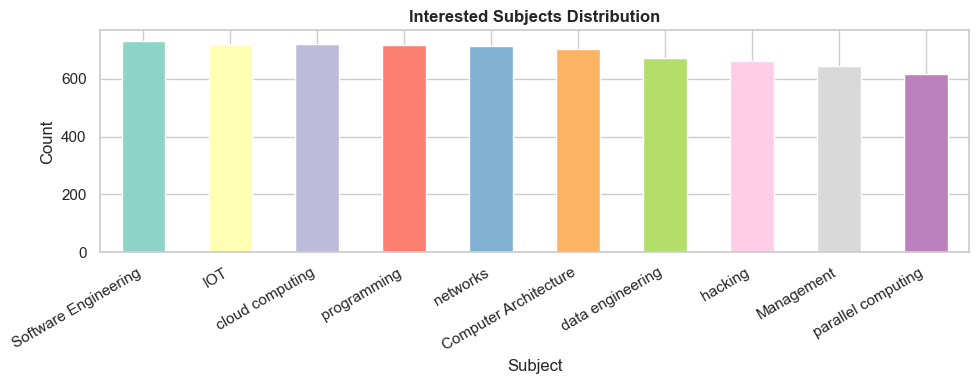

Plot saved: subjects_distribution.png

  EDA SUMMARY
  Total students        : 6901
  Total features        : 19
  Target (Job Roles)    : 12 unique
  Numeric features      : 4
  Categorical features  : 15
  Missing values        : 0
  Duplicate rows        : 0


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100


df = pd.read_csv('../data/PS2_Dataset.csv')

print("=" * 55)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print("=" * 55)


print("\n── Column Names ──")
print(df.columns.tolist())

print("\n── Data Types ──")
print(df.dtypes)

print("\n── First 5 Rows ──")
print(df.head())

print("\n── Dataset Info ──")
df.info()


print("\n── Missing Values ──")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found ✓")


dupes = df.duplicated().sum()
print(f"\n── Duplicate Rows: {dupes} ──")


print("\n── Unique Job Roles (Target) ──")
job_counts = df['Suggested Job Role'].value_counts()
print(job_counts)
print(f"\nTotal unique roles: {df['Suggested Job Role'].nunique()}")

plt.figure(figsize=(14, 6))
job_counts.plot(kind='bar', color=sns.color_palette("muted", len(job_counts)))
plt.title('Distribution of Suggested Job Roles', fontsize=14, fontweight='bold')
plt.xlabel('Job Role')
plt.ylabel('Number of Students')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../models/job_role_distribution.png')
plt.show()
print("Plot saved: job_role_distribution.png")


numeric_cols = ['Logical quotient rating', 'hackathons',
                'coding skills rating', 'public speaking points']

print("\n── Numeric Column Statistics ──")
print(df[numeric_cols].describe())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=10, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../models/numeric_distributions.png')
plt.show()
print("Plot saved: numeric_distributions.png")

plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues',
            square=True, linewidths=0.5)
plt.title('Correlation Between Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/correlation_heatmap.png')
plt.show()
print("Plot saved: correlation_heatmap.png")


categorical_cols = [
    'self-learning capability?', 'Extra-courses did',
    'certifications', 'workshops', 'reading and writing skills',
    'memory capability score', 'Interested subjects',
    'interested career area ', 'Type of company want to settle in?',
    'Taken inputs from seniors or elders', 'Interested Type of Books',
    'Management or Technical', 'hard/smart worker',
    'worked in teams ever?', 'Introvert'
]

print("\n── Categorical Column Unique Values ──")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

key_cats = [
    'self-learning capability?',
    'Management or Technical',
    'hard/smart worker',
    'worked in teams ever?',
    'Introvert',
    'Extra-courses did'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=sns.color_palette("pastel", len(counts)))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Key Categorical Feature Distributions', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../models/categorical_distributions.png')
plt.show()
print("Plot saved: categorical_distributions.png")

plt.figure(figsize=(10, 4))
cert_counts = df['certifications'].value_counts()
cert_counts.plot(kind='bar', color=sns.color_palette("Set2", len(cert_counts)))
plt.title('Certifications Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Certification')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../models/certifications_distribution.png')
plt.show()
print("Plot saved: certifications_distribution.png")

plt.figure(figsize=(10, 4))
subj_counts = df['Interested subjects'].value_counts()
subj_counts.plot(kind='bar', color=sns.color_palette("Set3", len(subj_counts)))
plt.title('Interested Subjects Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../models/subjects_distribution.png')
plt.show()
print("Plot saved: subjects_distribution.png")


print("\n" + "=" * 55)
print("  EDA SUMMARY")
print("=" * 55)
print(f"  Total students        : {df.shape[0]}")
print(f"  Total features        : {df.shape[1] - 1}")
print(f"  Target (Job Roles)    : {df['Suggested Job Role'].nunique()} unique")
print(f"  Numeric features      : {len(numeric_cols)}")
print(f"  Categorical features  : {len(categorical_cols)}")
print(f"  Missing values        : {df.isnull().sum().sum()}")
print(f"  Duplicate rows        : {df.duplicated().sum()}")
print("=" * 55)
